# SSNAL Warm-Start Initialization Experiment (with PDHG-Net)

This notebook mirrors the PDHG warm-start experiment structure, but uses SSNAL as the solver and compares initializations from data, random, and PDHG-net.


In [1]:
cd /home/sam/cc-net

/home/sam/cc-net


/home/sam/anaconda3/envs/py10-coreset/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import os
import sys
import time
import random
import importlib
from pathlib import Path

# sys.path.insert(0, "/Users/chester/Documents/cc-net")

import numpy as np
import matplotlib.pyplot as plt
import torch
import yaml

import graphlearning as gl
import sklearn.datasets as skdatasets

import models.models as Models
import losses.losses as Losses
from models.model_utils import project_l2
from datasets.dataset_utils import graphlearning_to_pyg

import algorithms as alg
alg = importlib.reload(alg)

from tqdm.auto import tqdm, trange
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


In [3]:
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = "cpu"

# model config/checkpoint
cwd = Path.cwd()
notebook_dir = cwd / "notebooks" if (cwd / "notebooks").exists() else cwd
exp_file = notebook_dir / "cfg-pdhg.yaml"
model_pth = notebook_dir / "lambda-2.0.pt"

# SSNAL params
lam = 10.0
ssnal_tau = 0.35
ssnal_sigma = 0.5
ssnal_iters = 200

# 2-moons trial params
n_trials = 2
n_samples = 500
noise = 0.15
k_neighbors = 8
kernel = "gaussian"

# warm-start setup
warm_pdhg_iters = 20
pdhg_tau = 0.35
pdhg_sigma = 0.35

# plotting
error_every = 10
objective_rel_tol = 0.01


In [4]:
def load_model(model_cfg, model_pth, device="cpu"):
    model_class = getattr(Models, model_cfg["model"])
    model = model_class(**model_cfg["cfg"]).float().to(device)

    ckpt = torch.load(model_pth, map_location=device)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state = ckpt["model_state_dict"]
    else:
        state = ckpt

    model.load_state_dict(state)
    model.eval()
    return model


def make_two_moons_graph(n_samples, noise, k_neighbors, kernel, random_state):
    X, y = skdatasets.make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    X = X - X.mean(0)
    W = gl.weightmatrix.knn(X, k=k_neighbors, kernel=kernel)
    W.setdiag(0)
    W.eliminate_zeros()
    data = graphlearning_to_pyg(X, W)
    data.y = torch.from_numpy(y.astype(np.int64))
    return data


@torch.no_grad()
def pdhg_net_init(model, data, device="cpu"):
    data = data.to(device)
    src, dst = data.edge_index
    e0 = data.x[src] - data.x[dst]
    U, P = model(
        h=data.x.float(),
        e=e0.float(),
        edge_index=data.edge_index.long(),
        w=data.edge_attr.float(),
        x=data.x.float(),
    )

    for _ in range(20):
        U, P = model(
            h=U,
            e=P,
            edge_index=data.edge_index.long(),
            w=data.edge_attr.float(),
            x=data.x.float(),
        )

    w = data.edge_attr.float()
    sqrt_w = w.sqrt()

    return U.detach(), P.detach()


def random_init(X, m, lam, w, seed=None):
    n, d = X.shape
    g = torch.Generator(device=X.device)
    if seed is not None:
        g.manual_seed(seed)

    mean = X.mean(dim=0, keepdim=True)
    std = X.std(dim=0, keepdim=True, unbiased=False).clamp_min(1e-6)
    U0 = mean + std * torch.randn((n, d), generator=g, device=X.device, dtype=X.dtype)

    sqrtw = w.sqrt()
    r = lam * sqrtw
    Praw = torch.randn((m, d), generator=g, device=X.device, dtype=X.dtype)
    P0 = project_l2(Praw, r)
    return U0, P0


In [5]:
def run_ssnal_history(
    X,
    src,
    dst,
    w,
    lam,
    tau,
    sigma,
    iters,
    U0=None,
    P0=None,
    store_trajectory=False,
):
    alg_current = importlib.reload(alg)
    n, d = X.shape
    m = src.numel()

    sigma_k = max(float(sigma), 1e-6)

    Xk = X.clone() if U0 is None else U0.to(dtype=X.dtype, device=X.device).clone()
    if P0 is None:
        Zk = torch.zeros((m, d), dtype=X.dtype, device=X.device)
    else:
        sqrtw = w.sqrt().clamp_min(1e-12).view(-1, 1)
        Zk = sqrtw * P0.to(dtype=X.dtype, device=X.device)

    hist = {"obj": [], "pdg": [], "kkt": []}
    traj = {"U": []} if store_trajectory else None

    max_newton_iters = 30
    cg_max_iters = min(400, max(40, 2 * n))

    for k in trange(iters):
        alm_epsilon_k = min(1e-2, 1.0 / float((k + 1) ** 2))
        subproblem_tol = alm_epsilon_k / max(1.0, sigma_k**0.5)

        Xk = alg_current._ssncg_subproblem(
            A=X,
            src=src,
            dst=dst,
            w=w,
            lam=lam,
            sigma_k=sigma_k,
            Zk=Zk,
            X0=Xk,
            tau=tau,
            max_newton_iters=max_newton_iters,
            cg_max_iters=cg_max_iters,
            stopping_tol=subproblem_tol,
        )

        Dk = alg_current._graph_difference(Xk, src, dst) + Zk / sigma_k
        Uk = alg_current._weighted_group_l2_shrinkage(Dk, (lam * w) / sigma_k)
        primal_residual = alg_current._graph_difference(Xk, src, dst) - Uk
        Zk = Zk + sigma_k * primal_residual

        Pk = Zk / w.sqrt().clamp_min(1e-12).view(-1, 1)

        hist["obj"].append(float(Losses.energy(Xk, X, src, dst, w, lam)))
        hist["pdg"].append(float(Losses.energy_pdg(Xk, X, Pk, src, dst, w, lam)))
        hist["kkt"].append(float(Losses.kkt_residuals(Xk, Pk, X, src, dst, w, lam)["kkt_rel"]))

        if store_trajectory:
            traj["U"].append(Xk.detach().cpu().numpy())

    return Xk, Pk, hist, traj


In [6]:
datapth = '/data/sam/primal-dual/data/hierarchical_blobs_n_graphs=1000_branching=[2, 2, 2]_level_scales=[13.0, 6.0, 2.0]_points_per_leaf=10_seed=42_k=15_normalize=True-val.pt'
dataset = torch.load(datapth)
data = dataset[0]

In [7]:
unique_tuples = sorted(set(graph.labels))  # optional: sorted gives deterministic labels
tuple_to_label = {t: i for i, t in enumerate(unique_tuples)}

labels = [tuple_to_label[t] for t in graph.labels]

NameError: name 'graph' is not defined

In [7]:
def plot_graph(X, edge_index, ax, labels=None):
    for i, j in zip(edge_index[0], edge_index[1]):
        ax.plot([X[i,0], X[j,0]], [X[i,1], X[j,1]], color='0.8', alpha=0.8, zorder=1) 
    if labels:
        ax.scatter(X[:, 0], X[:, 1], edgecolors='none',  c=labels, cmap='tab10', zorder=2, s=10)
    else:
        ax.scatter(X[:, 0], X[:, 1], edgecolors='none', color='red', zorder=2, s=10)

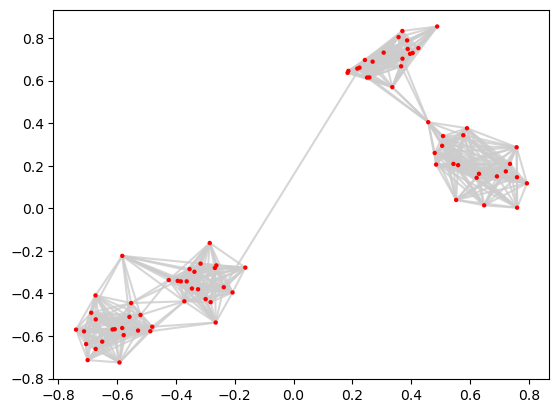

In [8]:
fig, ax = plt.subplots()
plot_graph(data.x, data.edge_index, ax)

In [10]:
X = data.x.float()
src, dst = data.edge_index.long()
w = data.edge_attr.float()
m = src.numel()
d = X.shape[1]

init_map = {}
init_map["data"] = (X.clone(), torch.zeros((m, d), device=device, dtype=X.dtype))
results = {}
for lam in [0.01, 0.025, 0.1, 10, 100]:
    U0, P0 = init_map['data']
    Xk, Pk, hist, _ = run_ssnal_history(
        X=X,
        src=src,
        dst=dst,
        w=w,
        lam=lam,
        tau=ssnal_tau,
        sigma=ssnal_sigma,
        iters=ssnal_iters,
        U0=U0,
        P0=P0,
        store_trajectory=False,
    )
    results[lam] = Xk

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

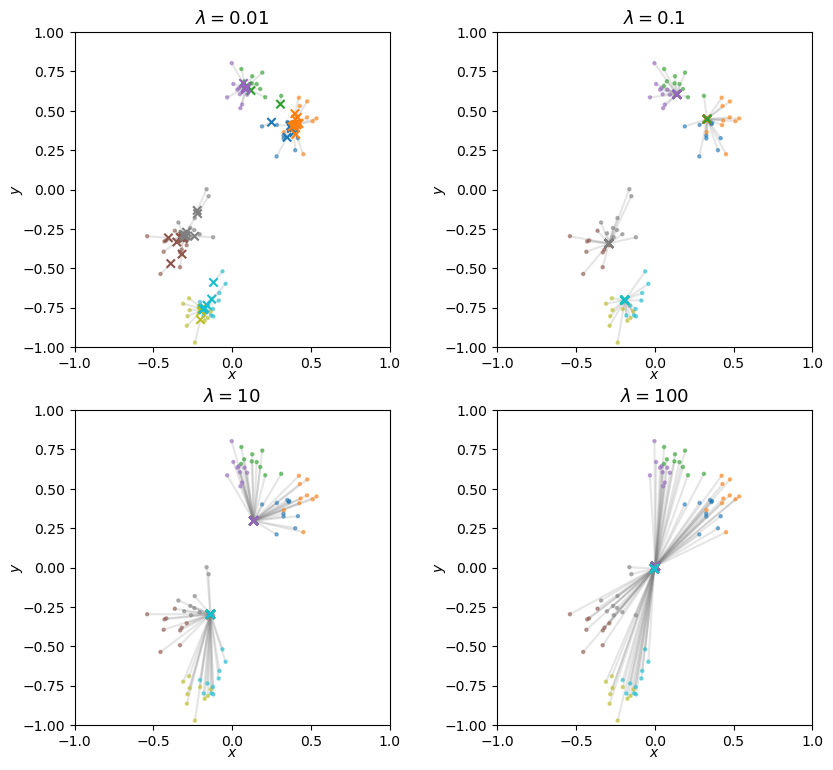

In [70]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 9))
ax_lbls = [(0,0), (0, 1), (1, 0), (1, 1)]
lambdas = [0.01, 0.1, 10, 100]
for i in range(4):
    lam=lambdas[i]
    Xk = results[lam]
    x = ax_lbls[i][0]
    y = ax_lbls[i][1]
    X = data.x
    for i in range(len(Xk)):
        ax[x][y].plot([X[i, 0], Xk[i, 0]], [X[i, 1], Xk[i, 1]], c='gray', alpha=0.2, zorder=1)
    ax[x][y].scatter(data.x[:, 0], data.x[:, 1], c=labels, cmap='tab10', alpha=0.5, s=5)
    ax[x][y].scatter(Xk[:, 0], Xk[:, 1], c=labels, cmap='tab10',marker='x' )
    ax[x][y].set_title(f'$\lambda={lam}$',fontsize=13)
    ax[x][y].set_ylabel('$y$', fontsize=10, labelpad=-2)
    ax[x][y].set_xlabel('$x$', fontsize=10, labelpad=-2)
    ax[x][y].set_aspect('equal')
    ax[x][y].set_ylim(-1, 1)
    ax[x][y].set_xlim(-1, 1)

In [71]:
fig.savefig('notebooks/images/cc-example.pdf')

In [9]:
exp_file = '/home/sam/cc-net/configs/single-runs/hierarchical-gaussians/pdhg/lam0.01.yaml'
with open(exp_file, "r") as f:
    exp_cfg = yaml.safe_load(f)

model_cfg = exp_cfg["model_config"]
if lam is None:
    lam = float(model_cfg["cfg"].get("lam", 1.0))
model_pth = '/data/sam/primal-dual/energy_pdg/hierarchical_blobs/EncodeProcessDecode/GraphPDHGNet/PDHGLayer_L5_H256_inN128_inE128_lam0.01_tau0.35_sig0.35_resid=False_steps=1_featDim=2/d6vrsgha/final.pt'
if not model_pth:
    raise ValueError("Set model_pth to a trained PDHG-Net checkpoint.")
lam=0.01
model = load_model(model_cfg, model_pth, device=device)
print(f"Loaded model: {model_cfg['model']}")
print(f"lam={lam}, ssnal_tau={ssnal_tau}, ssnal_sigma={ssnal_sigma}, ssnal_iters={ssnal_iters}")
print(f"warm_pdhg_iters={warm_pdhg_iters}, pdhg_tau={pdhg_tau}, pdhg_sigma={pdhg_sigma}")

Loaded model: EncodeProcessDecode
lam=0.01, ssnal_tau=0.35, ssnal_sigma=0.5, ssnal_iters=200
warm_pdhg_iters=20, pdhg_tau=0.35, pdhg_sigma=0.35


In [13]:
#methods = ["data", "random", "pdhg_net"]
methods = ["data", "pdhg_net"]
results = {m: {"obj": [], "pdg": [], "kkt": []} for m in methods}
trials = []
n_trials=10
print("edge memory", model.processor.layers[0].dual_scaling)

for t in range(n_trials):
    g = make_two_moons_graph(
        n_samples=n_samples,
        noise=noise,
        k_neighbors=k_neighbors,
        kernel=kernel,
        random_state=seed + t,
    )
    trials.append(g)

for t, g in enumerate(tqdm(trials, desc="SSNAL trials")):
    data = g.to(device)
    X = data.x.float()
    src, dst = data.edge_index.long()
    w = data.edge_attr.float()
    m = src.numel()
    d = X.shape[1]

    init_map = {}
    init_map["data"] = (X.clone(), torch.zeros((m, d), device=device, dtype=X.dtype))
    init_map["random"] = random_init(X, m, lam, w, seed=seed + t)

    U0_net, P0_net = pdhg_net_init(model, g, device=device)
    P0_net = project_l2(P0_net, lam * w.sqrt())
    init_map["pdhg_net"] = (U0_net, P0_net)

    for mname in methods:
        U0, P0 = init_map[mname]
        _, _, hist, _ = run_ssnal_history(
            X=X,
            src=src,
            dst=dst,
            w=w,
            lam=lam,
            tau=ssnal_tau,
            sigma=ssnal_sigma,
            iters=ssnal_iters,
            U0=U0,
            P0=P0,
            store_trajectory=False,
        )
        results[mname]["obj"].append(hist["obj"])
        results[mname]["pdg"].append(hist["pdg"])
        results[mname]["kkt"].append(hist["kkt"])


edge memory 0


/home/sam/anaconda3/envs/py10-coreset/lib/python3.10/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


SSNAL trials:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

In [14]:
def arr(method, key):
    return np.asarray(results[method][key], dtype=np.float64)


def first_hit(curve, target):
    idx = np.where(curve <= target)[0]
    return float(idx[0]) if len(idx) > 0 else np.nan


iter_summary = {m: [] for m in methods}
for t in range(n_trials):
    finals = [arr(m, "obj")[t, -1] for m in methods]
    best_final = min(finals)
    target = best_final * (1.0 + objective_rel_tol)
    for m in methods:
        iter_summary[m].append(first_hit(arr(m, "obj")[t], target))

print(f"Trials: {n_trials}, n_samples={n_samples}, noise={noise}, k={k_neighbors}")
print(f"Objective target: (1 + {objective_rel_tol:.2%}) * best final objective")
for m in methods:
    it = np.asarray(iter_summary[m], dtype=np.float64)
    print(f"{m:9s} | mean_iter={np.nanmean(it):8.2f} | median_iter={np.nanmedian(it):8.2f} | hit_rate={np.mean(~np.isnan(it)):6.2%}")

print("\nFinal values across trials (mean +/- std):")
for m in methods:
    o = arr(m, "obj")[:, -1]
    g = arr(m, "pdg")[:, -1]
    k = arr(m, "kkt")[:, -1]
    print(f"{m:9s} | obj={o.mean():.6f} +/- {o.std():.6f} | pdg={g.mean():.3e} +/- {g.std():.3e} | kkt={k.mean():.3e} +/- {k.std():.3e}")


Trials: 10, n_samples=500, noise=0.15, k=8
Objective target: (1 + 1.00%) * best final objective
data      | mean_iter=    0.00 | median_iter=    0.00 | hit_rate=100.00%
pdhg_net  | mean_iter=    1.00 | median_iter=    1.00 | hit_rate=100.00%

Final values across trials (mean +/- std):
data      | obj=0.247774 +/- 0.007529 | pdg=1.371e-07 +/- 1.446e-07 | kkt=4.440e-04 +/- 7.905e-04
pdhg_net  | obj=0.247774 +/- 0.007529 | pdg=8.494e-08 +/- 4.899e-08 | kkt=4.185e-04 +/- 8.361e-04


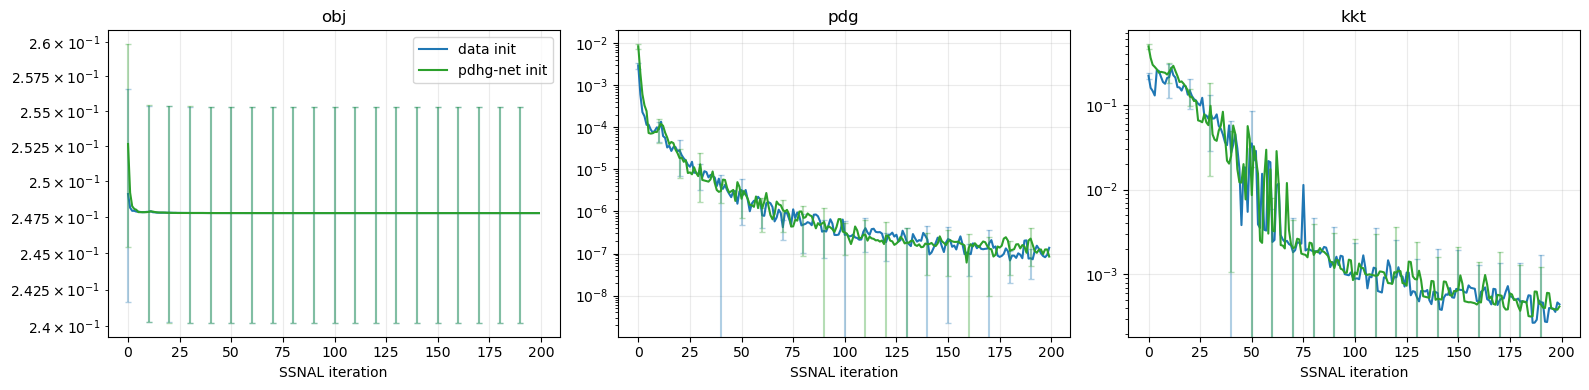

In [15]:
colors = {"data": "tab:blue", "random": "tab:orange", "pdhg_net": "tab:green"}
labels = {"data": "data init", "random": "random init", "pdhg_net": "pdhg-net init"}

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
for metric, ax in zip(["obj", "pdg", "kkt"], axs):
    for m in methods:
        A = arr(m, metric)
        mu = A.mean(axis=0)
        sd = A.std(axis=0)
        x = np.arange(A.shape[1])

        ax.plot(x, mu, color=colors[m], label=labels[m])

        xe = x[::error_every]
        mue = mu[::error_every]
        sde = sd[::error_every]
        ax.errorbar(xe, mue, yerr=sde, fmt="none", ecolor=colors[m], alpha=0.35, capsize=2)

    if metric in {"obj", "pdg", "kkt"}:
        ax.set_yscale("log")
    ax.set_title(metric)
    ax.set_xlabel("SSNAL iteration")
    ax.grid(alpha=0.25)

axs[0].legend(loc="best")
plt.tight_layout()
plt.show()


In [ ]:
# animation: SSNAL trajectory from selected initialization
anim_trial = 0
anim_init = "pdhg_net"   # "data", "random", "pdhg_net"
anim_stride = 4
save_gif = True
gif_path = "./ssnal-trajectory-kkt.gif"
gif_fps = 12

if "trials" in globals() and len(trials) > 0:
    g_anim = trials[anim_trial % len(trials)]
else:
    g_anim = make_two_moons_graph(
        n_samples=n_samples,
        noise=noise,
        k_neighbors=k_neighbors,
        kernel=kernel,
        random_state=seed + anim_trial,
    )

data = g_anim.to(device)
X = data.x.float()
src, dst = data.edge_index.long()
w = data.edge_attr.float()
y = data.y.cpu().numpy()
m = src.numel()
d = X.shape[1]

if anim_init == "data":
    U0 = X.clone()
    P0 = torch.zeros((m, d), device=device, dtype=X.dtype)
elif anim_init == "random":
    U0, P0 = random_init(X, m, lam, w, seed=seed + anim_trial)
elif anim_init == "pdhg_net":
    U0, P0 = pdhg_net_init(model, g_anim, device=device)
    P0 = project_l2(P0, lam * w.sqrt())
else:
    raise ValueError(f"Unknown anim_init={anim_init!r}")

U_fin, P_fin, hist_anim, traj_anim = run_ssnal_history(
    X=X,
    src=src,
    dst=dst,
    w=w,
    lam=lam,
    tau=ssnal_tau,
    sigma=ssnal_sigma,
    iters=ssnal_iters,
    U0=U0,
    P0=P0,
    store_trajectory=True,
)

U_frames = traj_anim["U"]
frame_idx = list(range(0, len(U_frames), anim_stride))
if frame_idx[-1] != len(U_frames) - 1:
    frame_idx.append(len(U_frames) - 1)

fig, (ax_scatter, ax_metric) = plt.subplots(1, 2, figsize=(12, 5))

u0 = U_frames[0]
sc = ax_scatter.scatter(u0[:, 0], u0[:, 1], c=y, s=10, cmap="coolwarm")
ax_scatter.set_title(f"SSNAL trajectory ({anim_init} init)")
ax_scatter.set_xlim(np.min(X[:, 0].cpu().numpy()) - 0.2, np.max(X[:, 0].cpu().numpy()) + 0.2)
ax_scatter.set_ylim(np.min(X[:, 1].cpu().numpy()) - 0.2, np.max(X[:, 1].cpu().numpy()) + 0.2)
ax_scatter.grid(alpha=0.2)

x_full = np.arange(1, len(hist_anim["obj"]) + 1)
line_pdg, = ax_metric.semilogy([], [], color="tab:green", label="pdg")
line_kkt, = ax_metric.semilogy([], [], color="tab:red", label="kkt")
ax_metric.set_xlabel("SSNAL iteration")
ax_metric.set_ylabel("pdg / kkt (log)")
ax_metric.grid(alpha=0.25)

ax_obj = ax_metric.twinx()
line_obj, = ax_obj.plot([], [], color="tab:blue", linestyle="--", label="objective")
ax_obj.set_ylabel("objective")

lines = [line_obj, line_pdg, line_kkt]
labels = [ln.get_label() for ln in lines]
ax_metric.legend(lines, labels, loc="upper right")

status_text = ax_metric.text(0.02, 0.02, "", transform=ax_metric.transAxes)

def update(frame_no):
    t = frame_idx[frame_no]
    U_t = U_frames[t]
    sc.set_offsets(U_t[:, :2])

    xx = x_full[: t + 1]
    obj_t = np.asarray(hist_anim["obj"][: t + 1], dtype=float)
    pdg_t = np.asarray(hist_anim["pdg"][: t + 1], dtype=float)
    kkt_t = np.asarray(hist_anim["kkt"][: t + 1], dtype=float)

    line_obj.set_data(xx, obj_t)
    line_pdg.set_data(xx, pdg_t)
    line_kkt.set_data(xx, kkt_t)

    ax_metric.set_xlim(1, max(2, len(x_full)))
    pdgkkt_min = min(float(np.nanmin(pdg_t)), float(np.nanmin(kkt_t)))
    pdgkkt_max = max(float(np.nanmax(pdg_t)), float(np.nanmax(kkt_t)))
    ax_metric.set_ylim(max(pdgkkt_min * 0.8, 1e-10), pdgkkt_max * 1.2)

    obj_min = float(np.nanmin(obj_t))
    obj_max = float(np.nanmax(obj_t))
    if obj_max == obj_min:
        obj_max = obj_min + 1e-6
    ax_obj.set_ylim(obj_min - 0.05 * (obj_max - obj_min), obj_max + 0.05 * (obj_max - obj_min))

    status_text.set_text(
        f"iter={t+1}\nobj={obj_t[-1]:.6f}\npdg={pdg_t[-1]:.3e}\nkkt={kkt_t[-1]:.3e}"
    )

    return sc, line_obj, line_pdg, line_kkt, status_text

ani = FuncAnimation(fig, update, frames=len(frame_idx), interval=90, blit=False)
plt.tight_layout()

if save_gif:
    ani.save(gif_path, writer="pillow", fps=gif_fps)
    print(f"Saved GIF to {os.path.abspath(gif_path)}")

display(HTML(ani.to_jshtml()))
plt.close(fig)

Saved GIF to /Users/chester/Documents/cc-net/notebooks/ssnal-trajectory-kkt.gif


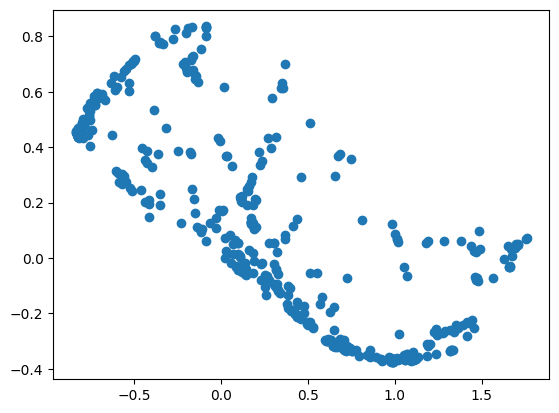

In [ ]:
plt.scatter(U0[:,0],U0[:,1])

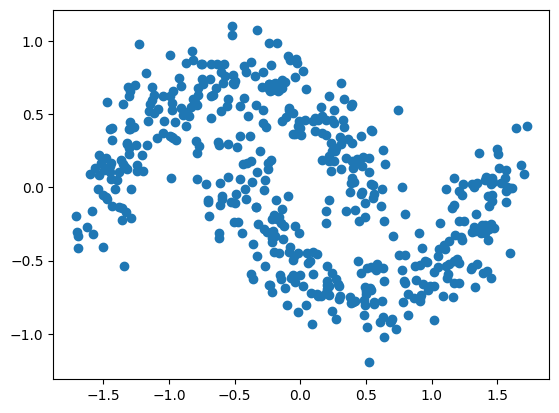

In [ ]:
plt.scatter(X[:,0],X[:,1])

### Notes
- This experiment compares SSNAL convergence under different initializations.
- `pdhg_net` initialization uses the PDHG-net prediction for both primal and dual warm starts.
- The animation cell defaults to `pdhg_net` initialization.
